# Markov Decision Process
Assume that we have the following grid world:

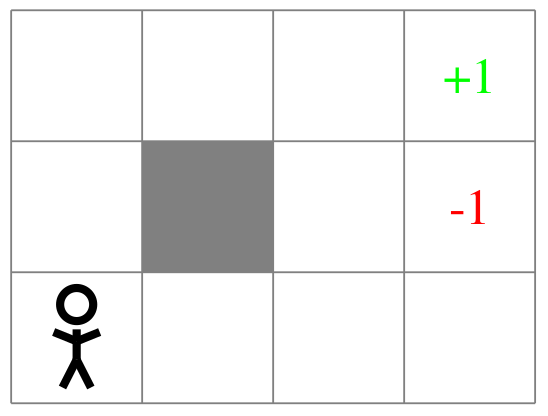

The goal of the agent whose position is at the bottom left corner is to maximize the expected future reward.

The top right (reward +1) and the middle right cell (reward -1) are terminal states.

There are four different actions the agent can choose, namely go up, down, left and right.

However, there is a chance that the agent will result in a wrong grid cell by accident.

If the action is going up, there is a chance of 0.8 that the agent moves up, a chance of 0.1 that he moves left and a chance of 0.1 that he moves right.

All other actions behave accordingly. If the agent would bounce on a wall it stays at the current position. Note that the agent cannot move through the grayed-out grid cell.
Assume a gamma value of  $\gamma=0.9$.

Assume that the following utility values are given:

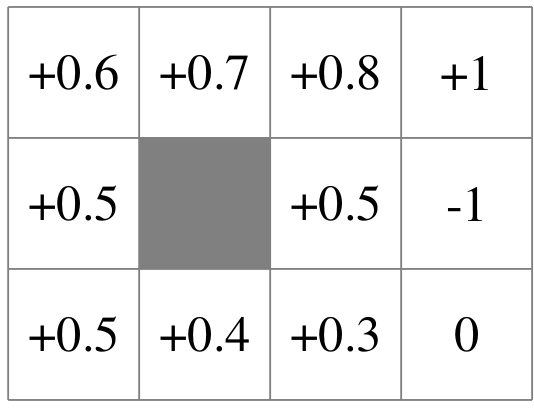

##Environment Definition:

In [177]:
import matplotlib.pyplot as plt
import numpy as np
import seaborn as sns

In [178]:
class MDP: #MDP:Markov Decission Process
  "4:up, 1:right, -1:left, -4:down"
  _transitions = np.array([
    [[4,0.8],[-1,0.1],[1,0.1]],#up
    [[1,0.8],[-4,0.1],[4,0.1]],#right
    [[-1,0.8],[-4,0.1],[4,0.1]],#left
    [[-4,0.8],[-1,0.1],[1,0.1]]#down
  ])

  def __init__(self, gamma=0.9):
    self.reward = np.zeros(3*4)
    self.reward[-1] = 1 #celda final vale +1
    self.reward[5] = -10 #celda gris
    self.reward[4] = -1 #celda roja vale -1
    self.gamma = gamma

  def rewards(self, state):
    return self.reward[state]

  def _bounces(self,state,s):
    return np.sum(np.abs(np.array(np.where(np.arange(12).reshape((3,4)) == state)) -
                         np.array(np.where(np.arange(12).reshape((3,4)) == s)))) > 1

  def transition(self, state, action):
    if state == 7 or state == 11:
      return np.zeros((0,2))
    trans = MDP._transitions[action].copy()
    trans = trans.T
    trans[0,:] += state
    trans = trans.T
    for i, (s,prob) in enumerate(trans):
      if s < 0 or s >= 12 or s == 5 or self._bounces(state,s):
        trans[i,0] = state
    return trans

In [179]:
utilities = np.array([0.5,0.4,0.3,0,
                      0.5,-10,0.5,-1,
                      0.6,0.7,0.8,1])

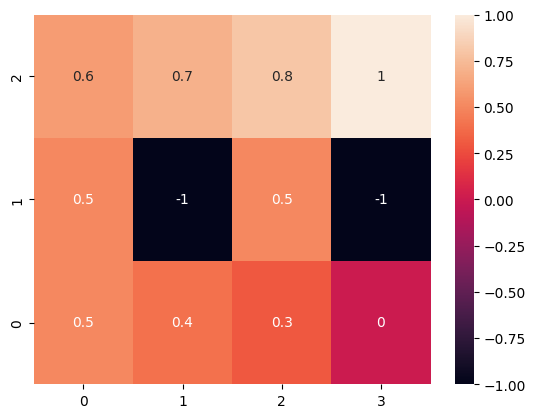

In [180]:
def show_utilities(ut):
  plt.figure()
  reshaped = ut.reshape((3,4))
  reshaped[1,1] = -1
  ax = sns.heatmap(reshaped, annot=True)
  ax.invert_yaxis()

show_utilities(utilities)

In [181]:
mdp = MDP()

## Value Iteration
Implement the value iteration algorithm.

In [182]:
def q(mdp, state, action, utilities):
  trans = mdp.transition(state,action)
  return np.sum(utilities[trans.T[0].astype(int)] * trans.T[1])

def value_iteration(mdp, utilities):
  ut_new = np.zeros(len(utilities)) #inicializar en 0
  n = 0
  delta = np.inf
  while delta > 1e-10:
    for state in range(len(utilities)):
      #U'[s] = R(s) + gama * max_a sum_s' P(s'|s,a)*U[s']
      ut_new[state] = mdp.rewards(state) + mdp.gamma * np.max([q(mdp,state,a,utilities) for a in range(4)])
    delta = np.max(np.abs(utilities - ut_new))
    utilities = ut_new.copy()
    n += 1
  print(n)
  return utilities

31


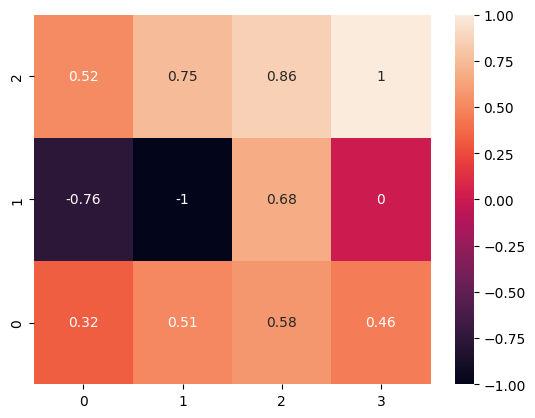

In [183]:
optimal = value_iteration(mdp, utilities)
#print(optimal)
show_utilities(optimal)

In [184]:
def extract_policy(position, qtable):
  qtable = qtable.reshape((3,4))
  policy = []
  path = [position]
  #print(position)
  while position[0] != 2 or position[1] != 3:
    neighborhood = []
    if position[0] > 0:
      neighborhood += [('down',qtable[position[0] - 1,position[1]])]
    if position[0] < 2:
      neighborhood += [('up',qtable[position[0] + 1,position[1]])]
    if position[1] > 0:
      neighborhood += [('left',qtable[position[0],position[1] - 1])]
    if position[1] < 3:
      neighborhood += [('right',qtable[position[0],position[1] + 1])]
    #print(neighborhood)
    action = [n[0] for n in neighborhood if n[1] == max([n1[1] for n1 in neighborhood])][0]
    #print(action)
    if action == 'down':
      position = (position[0] - 1, position[1])
    if action == 'up':
      position = (position[0] + 1, position[1])
    if action == 'right':
      position = (position[0], position[1] + 1)
    if action == 'left':
      position = (position[0], position[1] - 1)
    #print(position)
    policy += [action]
    path += [position]
  return policy,path

['right', 'right', 'up', 'up', 'right']
[(0, 0), (0, 1), (0, 2), (1, 2), (2, 2), (2, 3)]


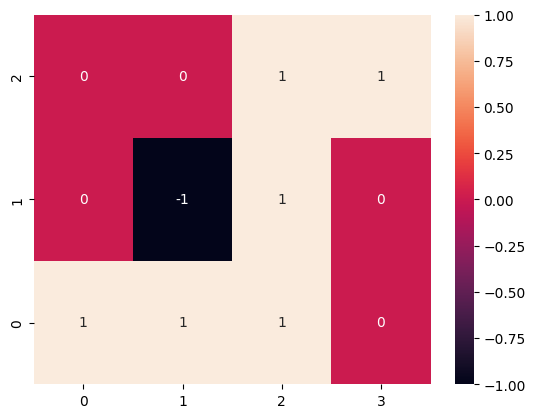

In [185]:
policy,path = extract_policy((0,0),optimal)
print(policy)
print(path)

opt = np.zeros(12).reshape((3,4))

for p in path:
  opt[p[0],p[1]] = 1
show_utilities(opt)

# Policy Evaluation
Implement a policy evaluation step in order evaluate the utility values of the improved policy.

In [186]:
def policy_improvement(mdp,policy):
  policy = np.zeros(len(utilities))
  for state in range(len(utilities)):
    policy[state] = np.argmax([q(mdp,state,a,utilities) for a in range(4)])
  return policy

In [187]:
def policy_evaluation(mdp,policy):
  states = len(policy)
  reward = [mdp.rewards(s) for s in range(states)]
  prob_matrix = np.eye(states)
  for state in range(states):
    trans = mdp.transition(state, policy[state])
    for i, (s,prob) in enumerate(trans):
      prob_matrix[state,int(s)] -= mdp.gamma * prob
  return np.linalg.solve(prob_matrix,reward)

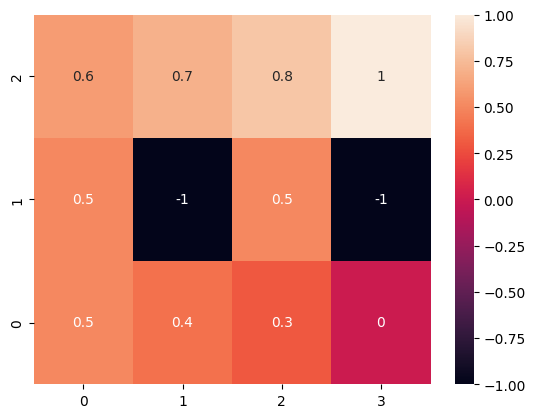

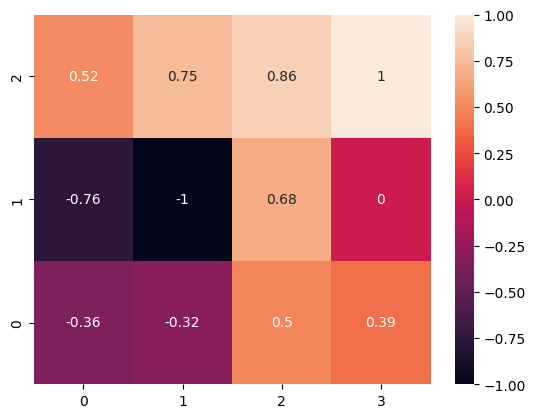

In [188]:
show_utilities(utilities)
show_utilities(policy_evaluation(mdp, policy_improvement(mdp,utilities).astype(int)))

In [189]:
def policy_iteration(mdp,utilities):
  policy = np.zeros(len(utilities),dtype=int)
  while True:
    utilities = policy_evaluation(mdp,policy)
    policy_next = policy_improvement(mdp, utilities).astype(int)
    if np.sum(policy_next != policy) == 0:
      break
    policy = policy_next
  return policy

[2 2 0 2 0 0 0 0 1 1 1 0]
[-0.36098646 -0.31696372  0.4957689   0.39225671 -0.76208254 -9.46480092
  0.6791563   0.          0.52096156  0.75369784  0.8583781   1.        ]


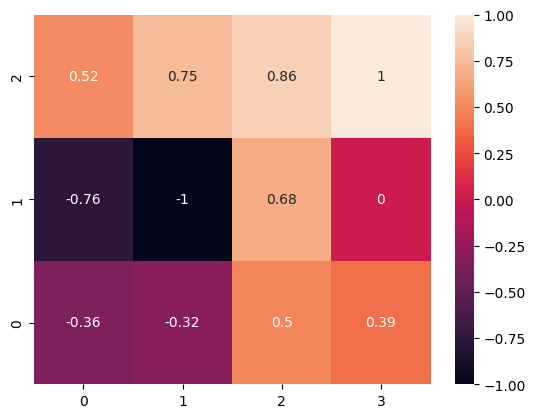

In [190]:
policy = policy_iteration(mdp, utilities)
print(policy)
optimal_ut = policy_evaluation(mdp, policy)
print(optimal_ut)
show_utilities(optimal_ut)

In [191]:
extract_policy((0,0), optimal_ut)

(['right', 'right', 'up', 'up', 'right'],
 [(0, 0), (0, 1), (0, 2), (1, 2), (2, 2), (2, 3)])

In [192]:
class MDP20:
    _transitions = np.array([
        [[20,0.8],[-1,0.1],[1,0.1]],
        [[1,0.8],[-20,0.1],[20,0.1]],
        [[-1,0.8],[-20,0.1],[20,0.1]],
        [[-20,0.8],[-1,0.1],[1,0.1]]
    ])

    def __init__(self, gamma=0.9):
        self.reward = np.zeros(20*20)
        self.reward[399] = 1
        self.reward[190] = -10
        self.reward[199] = -1
        self.gamma = gamma

    def rewards(self, state):
        return self.reward[state]

    def _bounces(self, state, s):
        r0, c0 = divmod(state, 20)
        r1, c1 = divmod(int(s), 20)
        return abs(r0 - r1) + abs(c0 - c1) > 1

    def transition(self, state, action):
        if state == 199 or state == 399:
            return np.zeros((0,2))
        trans = MDP20._transitions[action].copy()
        trans = trans.T
        trans[0,:] += state
        trans = trans.T
        for i, (s, prob) in enumerate(trans):
            if s < 0 or s >= 400 or s == 190 or self._bounces(state, s):
                trans[i,0] = state
        return trans


In [193]:
utilities20 = np.array([
    -0.7,  0.6, -0.0,  0.5,  1.0,  0.2,  0.1, -0.7, -0.3,  0.1,  0.4,  0.6, -0.1, -0.7, -0.3,  0.8, -0.4,  0.0,  0.9, -0.8,
     0.3,  0.9, -0.4,  0.2,  0.8, -0.6,  0.1,  0.6,  0.4,  0.0, -0.4,  0.1, -0.1,  0.1, -0.1,  0.7,  0.6, -0.2,  0.2, -0.3,
     0.0, -0.2,  0.4, -0.1,  0.0,  0.5, -0.1,  0.8, -.5,  0.5, -0.0, -0.0,  0.3,  0.1, -0.1, -0.8, -0.6,  0.5,  0.1,  0.5,
     0.9,  0.4, -0.7, -0.2,  0.3, -0.4,  0.9,  0.9,  0.7,  0.1,  0.7, -0.6, -0.2,  0.0,  0.5,  0.1, -0.6, -0.2, -0.2, -0.3,
    -0.5, -0.1,  0.0,  0.6,  0.6,  0.1,  0.0,  0.6,  0.8,  0.4,  0.6,  0.9, -0.7,  0.8, -0.3,  0.1,  0.6,  0.5, -0.5,  0.4,
    0.7, -0.2,  0.7, -0.0,  0.3,  0.5,  0.7,  0.6, -0.8, -0.0,  0.0, -0.7,  0.2,  0.3,  0.7,  0.9, -0.6, -0.4,  0.4, -0.6,
    -0.4,  0.2, -0.5,  0.6,  0.7, -0.7,  0.2,  0.6,  1.0, -0.3, -0.5,  0.8,  0.8, -0.4, -0.0,  0.5,  0.7, -0.5,  0.4,  0.7,
     0.2, -0.5, -0.7, -0.3,  0.7, -0.7, -0.8, -0.1, -0.7, -0.5, -0.8,  0.1,  0.5, -0.0, -0.6, -0.2,  0.3,  0.9,  1.0, -0.4,
    -0.8,  0.7,  0.9,  0.0,  0.6,  0.8,  0.3,  0.8, -0.8, -0.3, -0.3, -0.6,  0.8, -0.7,  0.4, -0.7, -0.2, -0.0, -0.5,  0.1,
     0.2, -0.2,  0.5, -0.5, -0.5, -0.2, -0.1, -0.4,  0.9,  0.7,-10.0, -0.1, -0.4,  0.0, -0.3,  0.1,  0.9, -0.1,  0.4, -1.0,
     0.6, -0.7,  0.5,  0.9,  0.3, -0.3,  0.4,  0.5,  0.4, -0.5,  1.0,  0.9, -0.0,  0.3, -0.7,  1.0,  0.7,  0.3,  0.6, 0.5,
    -0.2, -0.4,  0.3, -0.6,  0.8,  0.0,  0.0, -0.6,  0.4,  0.7,  0.3, -0.4,  0.6, -0.5,  0.7,  0.2, -0.3,  0.1,  0.3, -0.3,
     0.7, -0.0,  0.8,  0.7, -0.6,  0.4, -0.2,  0.6,  0.2,  0.0,  0.8, -0.7,  0.2, -0.2, -0.7,  0.6,  0.2,  0.8,  0.3, -0.2,
     1.0, -0.6, -0.7,  0.5, -0.1, -0.1,  0.8, -0.2,  0.8,  0.4, -0.2, -0.7, -0.4,  0.9, -0.1, -0.5, -0.3,  0.8, -0.5,  0.6,
    -.6,  0.9,  0.2, -0.7,  0.9, -0.2,  0.5,  0.1, -0.6, -.6, -0.5, -0.5, -0.7, -0.7,  0.9, -0.6,  0.1, -0.6, -0.4,  0.6,
     0.9,  0.0, -.8,  1.0, -0.7, -0.1,  0.2,  0.8,  0.7,  0.3, -0.1,  0.7,  0.8,  0.8,  0.5, -0.6, -0.3,  0.1,  0.1,  0.7,
    -0.4,  0.4, -0.1,  0.6, -0.4,  0.1, -0.6, -0.4,  0.9, -0.2,  0.8,  0.1, -0.7,  0.6, -0.7,  0.7, -0.8,  0.4, -0.5, -0.2,
     0.9,  0.1,  0.4,  0.5, -0.6,  0.7,  0.8, 0.5,  0.2, -0.3,  0.5, -0.7,  0.1,  0.6,  0.5, -0.6,  0.7, -.4,  0.7,  0.1,
    -0.5,  0.5,  0.7,  0.5,  0.9, -0.3, -0.4, 0.5,  0.2, -0.1, -0.2,  0.0, -.3, -0.8,  0.0, -0.3,  0.0,  0.9, -0.5,  0.3,
     0.4, -0.3,  0.0,  0.9, -0.2,  0.5,  0.7, -0.2,  1.0,  0.3,  0.1,  0.5, -0.0,  0.5, -0.3,  0.9,  0.2, -0.4, -0.0,  1.0,
])


utilities20[399] =  1    # meta   (+1)
utilities20[199] = -1    # trampa (-1)
utilities20[190] = -10   # celda gris


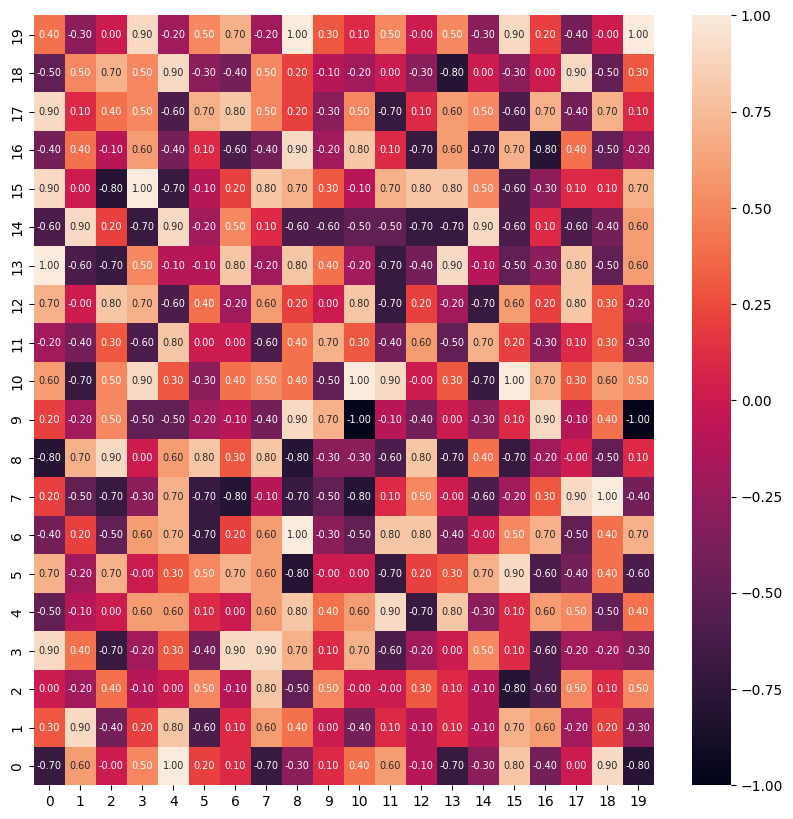

In [194]:
def show_utilities_20(ut):
    plt.figure(figsize=(10,10))
    reshaped = ut.reshape((20,20)).copy()
    reshaped[9,10] = -1
    ax = sns.heatmap(reshaped, annot=True, fmt='.2f', annot_kws={'size':7})
    ax.invert_yaxis()

show_utilities_20(utilities20)


77


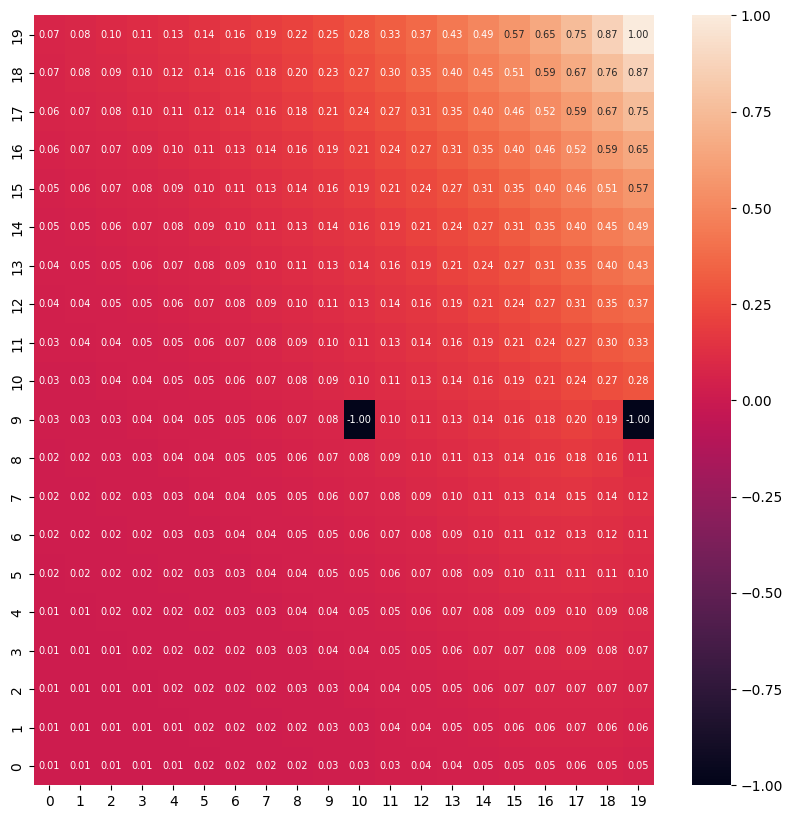

In [195]:
mdp20 = MDP20()

optimal20 = value_iteration(mdp20, utilities20)
show_utilities_20(optimal20)


In [196]:
def extract_policy_20(position, qtable):
    qtable = qtable.reshape((20,20))
    policy = []
    path = [position]
    while position[0] != 19 or position[1] != 19:
        neighborhood = []
        if position[0] > 0:
            neighborhood += [('down', qtable[position[0]-1,position[1]])]
        if position[0] < 19:
            neighborhood += [('up', qtable[position[0]+1,position[1]])]
        if position[1] > 0:
            neighborhood += [('left', qtable[position[0],position[1]-1])]
        if position[1] < 19:
            neighborhood += [('right', qtable[position[0],position[1]+1])]
        action = [n[0] for n in neighborhood if n[1] == max([n1[1] for n1 in neighborhood])][0]
        if action == 'down':
            position = (position[0]-1,position[1])
        if action == 'up':
            position = (position[0]+1,position[1])
        if action == 'right':
            position = (position[0],position[1]+1)
        if action == 'left':
            position = (position[0],position[1]-1)
        policy += [action]
        path += [position]
    return policy, path


['up', 'up', 'up', 'up', 'up', 'up', 'up', 'up', 'up', 'up', 'up', 'up', 'up', 'up', 'right', 'right', 'right', 'right', 'right', 'right', 'right', 'right', 'right', 'right', 'right', 'right', 'right', 'right', 'up', 'right', 'up', 'right', 'up', 'right', 'up', 'right', 'up', 'right']
[(0, 0), (1, 0), (2, 0), (3, 0), (4, 0), (5, 0), (6, 0), (7, 0), (8, 0), (9, 0), (10, 0), (11, 0), (12, 0), (13, 0), (14, 0), (14, 1), (14, 2), (14, 3), (14, 4), (14, 5), (14, 6), (14, 7), (14, 8), (14, 9), (14, 10), (14, 11), (14, 12), (14, 13), (14, 14), (15, 14), (15, 15), (16, 15), (16, 16), (17, 16), (17, 17), (18, 17), (18, 18), (19, 18), (19, 19)]


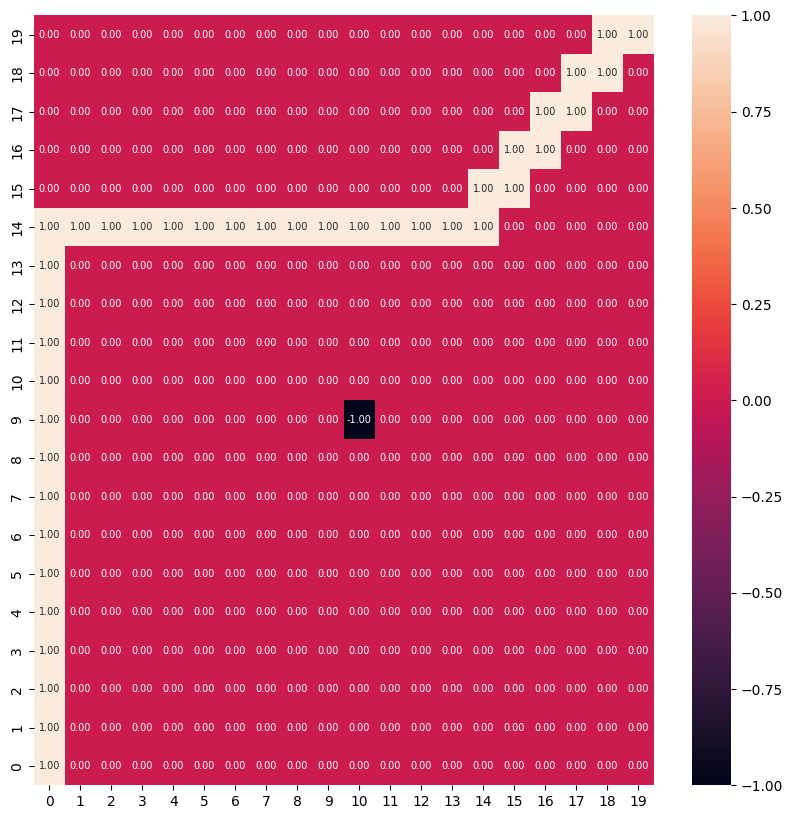

In [197]:
policy20, path20 = extract_policy_20((0,0), optimal20)
print(policy20)
print(path20)

opt20 = np.zeros(20*20).reshape((20,20))
for p in path20:
    opt20[p[0],p[1]] = 1
show_utilities_20(opt20)


In [198]:
def policy_improvement_20(mdp, ut):
    pol = np.zeros(len(ut))
    for state in range(len(ut)):
        pol[state] = np.argmax([q(mdp,state,a,ut) for a in range(4)])
    return pol

def policy_iteration_20(mdp, ut):
    pol = np.zeros(len(ut), dtype=int)
    while True:
        ut = policy_evaluation(mdp, pol)
        pol_next = policy_improvement_20(mdp, ut).astype(int)
        if np.sum(pol_next != pol) == 0:
            break
        pol = pol_next
    return pol


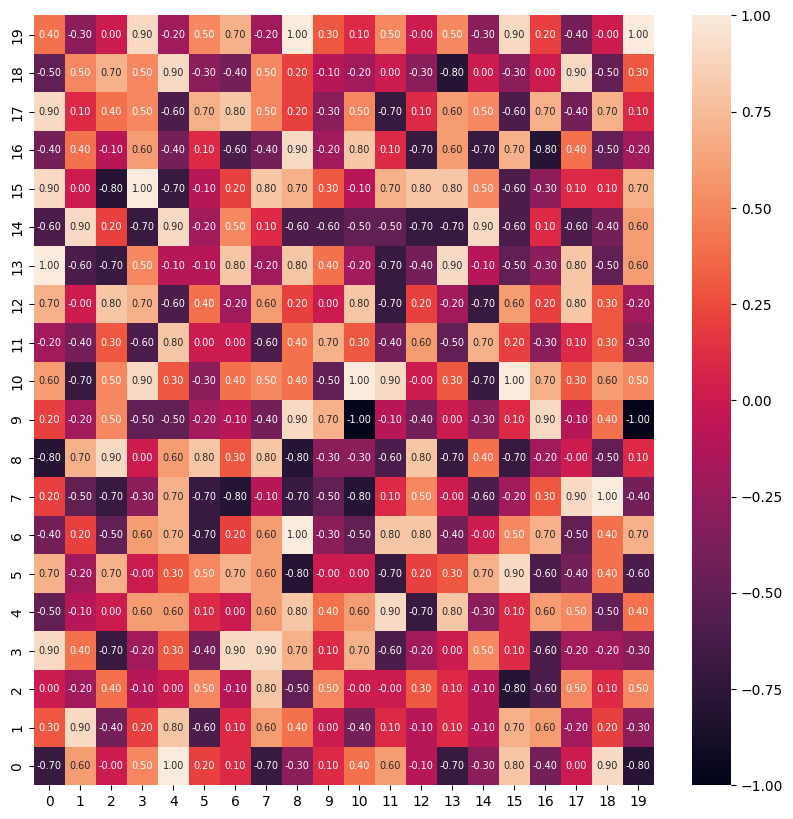

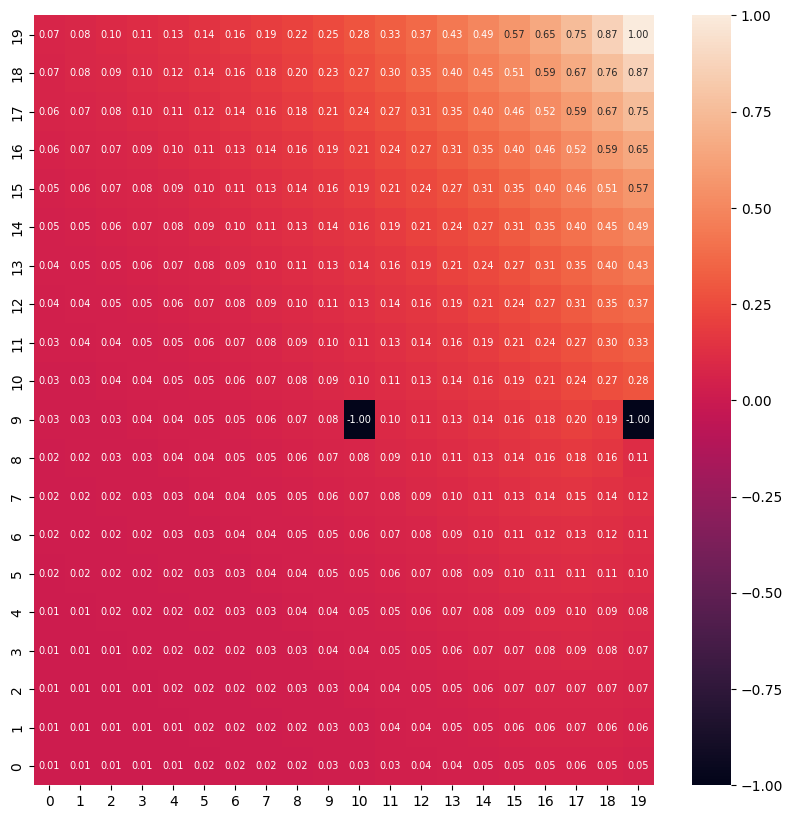

In [199]:
policy20_pi = policy_iteration_20(mdp20, utilities20)
optimal_ut20 = policy_evaluation(mdp20, policy20_pi)
show_utilities_20(utilities20)
show_utilities_20(optimal_ut20)


In [200]:
extract_policy_20((0,0), optimal_ut20)


(['up',
  'up',
  'up',
  'up',
  'up',
  'up',
  'up',
  'up',
  'up',
  'up',
  'up',
  'up',
  'up',
  'up',
  'right',
  'right',
  'right',
  'right',
  'right',
  'right',
  'right',
  'right',
  'right',
  'right',
  'right',
  'right',
  'right',
  'right',
  'up',
  'right',
  'up',
  'right',
  'right',
  'up',
  'up',
  'right',
  'up',
  'right'],
 [(0, 0),
  (1, 0),
  (2, 0),
  (3, 0),
  (4, 0),
  (5, 0),
  (6, 0),
  (7, 0),
  (8, 0),
  (9, 0),
  (10, 0),
  (11, 0),
  (12, 0),
  (13, 0),
  (14, 0),
  (14, 1),
  (14, 2),
  (14, 3),
  (14, 4),
  (14, 5),
  (14, 6),
  (14, 7),
  (14, 8),
  (14, 9),
  (14, 10),
  (14, 11),
  (14, 12),
  (14, 13),
  (14, 14),
  (15, 14),
  (15, 15),
  (16, 15),
  (16, 16),
  (16, 17),
  (17, 17),
  (18, 17),
  (18, 18),
  (19, 18),
  (19, 19)])